# 📚 Đồ án Học Máy và Ứng Dụng — Phân loại Spam SMS/Email

## Huấn luyện 7 mô hình + lưu file model cho ứng dụng Flask

**Sinh viên:** Trương Ngọc Như Muống — **MSSV:** 4551190036  
**GVHD:** Lê Quang Hùng — **Trường:** Đại học Quy Nhơn

---

**Pipeline:**

1. Load & EDA dataset `spam.csv`
2. Tiền xử lý văn bản
3. Vector hóa bằng TF-IDF
4. Train **5 mô hình ML cổ điển**: KNN, Naive Bayes, Decision Tree, KMeans, SVM
5. Train **2 mô hình Deep Learning**: LSTM (Keras), DistilBERT (Hugging Face)
6. Đánh giá và so sánh 7 mô hình
7. Lưu tất cả model vào thư mục `../models/` để Flask app sử dụng

## 1️⃣ Imports & Cấu hình

In [12]:
import os
import re
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)

MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Phiên bản các thư viện:')
import sklearn; print(f'  scikit-learn: {sklearn.__version__}')
print(f'  pandas:       {pd.__version__}')
print(f'  numpy:        {np.__version__}')

Phiên bản các thư viện:
  scikit-learn: 1.8.0
  pandas:       3.0.2
  numpy:        2.4.4


## 2️⃣ Load & khám phá dữ liệu

In [13]:
df = pd.read_csv('../data/spam.csv', encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'}).dropna()
df['label_enc'] = (df['label'] == 'spam').astype(int)

print(f'Tổng số mẫu: {len(df):,}')
print('\nPhân bố nhãn:')
print(df['label'].value_counts())
print(f'\nTỉ lệ Spam: {(df.label=="spam").mean()*100:.2f}%')
df.head(10)

Tổng số mẫu: 5,572

Phân bố nhãn:
label
ham     4825
spam     747
Name: count, dtype: int64

Tỉ lệ Spam: 13.41%


,label,text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1
6,ham,Even my brother is not like to speak with me. ...,0
7,ham,As per your request 'Melle Melle (Oru Minnamin...,0
8,spam,WINNER!! As a valued network customer you have...,1
9,spam,Had your mobile 11 months or more? U R entitle...,1


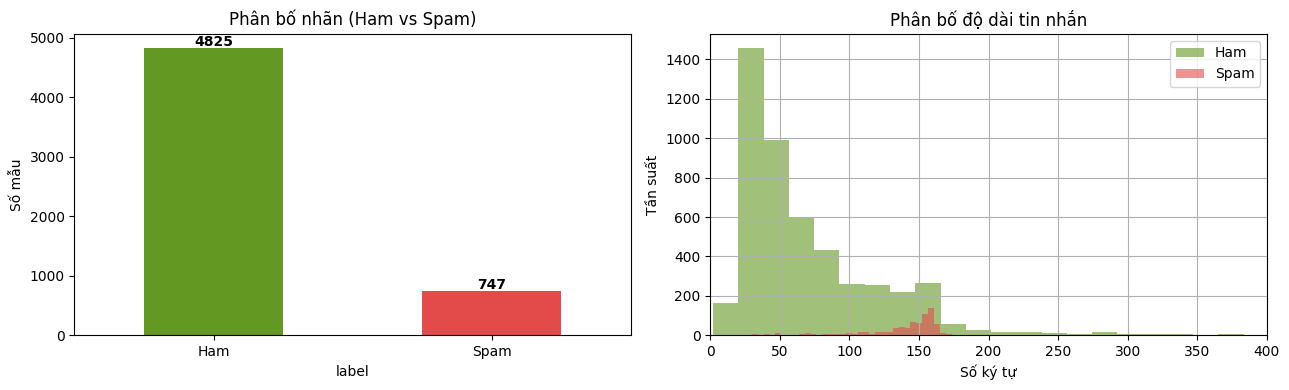

Độ dài trung bình: Ham = 71 ký tự, Spam = 139 ký tự


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['label'].value_counts().plot(kind='bar', ax=axes[0],
                                 color=['#639922', '#E24B4A'])
axes[0].set_title('Phân bố nhãn (Ham vs Spam)')
axes[0].set_ylabel('Số mẫu')
axes[0].set_xticklabels(['Ham', 'Spam'], rotation=0)
for i, v in enumerate(df['label'].value_counts()):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

df['text_len'] = df['text'].str.len()
df[df.label=='ham']['text_len'].hist(bins=50, alpha=0.6, label='Ham',
                                       color='#639922', ax=axes[1])
df[df.label=='spam']['text_len'].hist(bins=50, alpha=0.6, label='Spam',
                                       color='#E24B4A', ax=axes[1])
axes[1].set_title('Phân bố độ dài tin nhắn')
axes[1].set_xlabel('Số ký tự')
axes[1].set_ylabel('Tần suất')
axes[1].legend()
axes[1].set_xlim(0, 400)

plt.tight_layout()
plt.show()

print(f'Độ dài trung bình: Ham = {df[df.label=="ham"].text_len.mean():.0f} ký tự,'
      f' Spam = {df[df.label=="spam"].text_len.mean():.0f} ký tự')

## 3️⃣ Tiền xử lý văn bản

Các bước:
- Chuyển toàn bộ về chữ thường
- Thay số → token `NUM`
- Thay URL → token `URL`
- Loại bỏ các ký tự không phải chữ cái
- Chuẩn hóa khoảng trắng

In [15]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'\d+', 'NUM', text)
    text = re.sub(r'http\S+|www\S+', 'URL', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(preprocess)

print('--- Ví dụ trước/sau khi tiền xử lý ---')
for i in [0, 2, 5, 10]:
    print(f'\n[{df.iloc[i].label.upper()}]')
    print(f'  Gốc:    {df.iloc[i].text[:120]}')
    print(f'  Clean:  {df.iloc[i].text_clean[:120]}')

--- Ví dụ trước/sau khi tiền xử lý ---

[HAM]
  Gốc:    Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  Clean:  go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat

[SPAM]
  Gốc:    Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt r
  Clean:  free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry question std txt rate t c s apply 

[SPAM]
  Gốc:    FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std
  Clean:  freemsg hey there darling it s been week s now and no word back i d like some fun you up for it still tb ok xxx std chgs

[HAM]
  Gốc:    I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.
  Clean:  i m gonna be home soon and i don t want to

## 4️⃣ Chia tập Train/Test & Vector hóa TF-IDF

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text_clean'], df['label_enc'],
    test_size=0.2, random_state=RANDOM_STATE,
    stratify=df['label_enc']
)

print(f'Train: {len(X_train):,} mẫu  ·  Test: {len(X_test):,} mẫu')
print(f'Train spam ratio: {y_train.mean()*100:.2f}%')
print(f'Test  spam ratio: {y_test.mean()*100:.2f}%')

Train: 4,457 mẫu  ·  Test: 1,115 mẫu
Train spam ratio: 13.42%
Test  spam ratio: 13.36%


In [17]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f'Kích thước ma trận TF-IDF (train): {X_train_vec.shape}')
print(f'Kích thước ma trận TF-IDF (test):  {X_test_vec.shape}')
print(f'Số đặc trưng (vocabulary): {len(tfidf.vocabulary_):,}')

with open(f'{MODELS_DIR}/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print('\n✅ Đã lưu tfidf_vectorizer.pkl')

Kích thước ma trận TF-IDF (train): (4457, 5000)
Kích thước ma trận TF-IDF (test):  (1115, 5000)
Số đặc trưng (vocabulary): 5,000

✅ Đã lưu tfidf_vectorizer.pkl


## 5️⃣ Helper: Hàm đánh giá mô hình

In [19]:
all_results = {}

def evaluate(y_true, y_pred, model_name, store=True):
    acc  = accuracy_score(y_true, y_pred) * 100
    pre  = precision_score(y_true, y_pred, zero_division=0) * 100
    rec  = recall_score(y_true, y_pred, zero_division=0) * 100
    f1   = f1_score(y_true, y_pred, zero_division=0) * 100
    cm   = confusion_matrix(y_true, y_pred)

    print(f'\n=== {model_name} ===')
    print(f'  Accuracy:  {acc:.2f}%')
    print(f'  Precision: {pre:.2f}%')
    print(f'  Recall:    {rec:.2f}%')
    print(f'  F1-Score:  {f1:.2f}%')
    print(f'  Confusion Matrix:')
    print(f'    [[TN={cm[0,0]:4d}  FP={cm[0,1]:4d}]')
    print(f'     [FN={cm[1,0]:4d}  TP={cm[1,1]:4d}]]')

    if store:
        all_results[model_name] = {
            'Accuracy':  round(acc, 2),
            'Precision': round(pre, 2),
            'Recall':    round(rec, 2),
            'F1-Score':  round(f1, 2),
            'cm':        cm.tolist(),
        }
    return acc, pre, rec, f1

## 6️⃣ Huấn luyện 5 mô hình Machine Learning cổ điển

### 6.1. K-Nearest Neighbors (KNN)

In [20]:
knn = KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1)
knn.fit(X_train_vec, y_train)
y_pred_knn = knn.predict(X_test_vec)
evaluate(y_test, y_pred_knn, 'KNN')

with open(f'{MODELS_DIR}/knn.pkl', 'wb') as f:
    pickle.dump(knn, f)
print('✅ Đã lưu knn.pkl')


=== KNN ===
  Accuracy:  97.40%
  Precision: 96.88%
  Recall:    83.22%
  F1-Score:  89.53%
  Confusion Matrix:
    [[TN= 962  FP=   4]
     [FN=  25  TP= 124]]
✅ Đã lưu knn.pkl


### 6.2. Naive Bayes (Multinomial)

In [21]:
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_vec, y_train)
y_pred_nb = nb.predict(X_test_vec)
evaluate(y_test, y_pred_nb, 'Naive Bayes')

with open(f'{MODELS_DIR}/naive_bayes.pkl', 'wb') as f:
    pickle.dump(nb, f)
print('✅ Đã lưu naive_bayes.pkl')


=== Naive Bayes ===
  Accuracy:  98.12%
  Precision: 97.76%
  Recall:    87.92%
  F1-Score:  92.58%
  Confusion Matrix:
    [[TN= 963  FP=   3]
     [FN=  18  TP= 131]]
✅ Đã lưu naive_bayes.pkl


### 6.3. Decision Tree

In [22]:
dt = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=5,
    random_state=RANDOM_STATE,
)
dt.fit(X_train_vec, y_train)
y_pred_dt = dt.predict(X_test_vec)
evaluate(y_test, y_pred_dt, 'Decision Tree')

with open(f'{MODELS_DIR}/decision_tree.pkl', 'wb') as f:
    pickle.dump(dt, f)
print('✅ Đã lưu decision_tree.pkl')


=== Decision Tree ===
  Accuracy:  96.14%
  Precision: 90.15%
  Recall:    79.87%
  F1-Score:  84.70%
  Confusion Matrix:
    [[TN= 953  FP=  13]
     [FN=  30  TP= 119]]
✅ Đã lưu decision_tree.pkl


### 6.4. KMeans (k=2) — Mô hình không giám sát

KMeans là thuật toán **clustering**, không học nhãn. Để dùng cho phân loại:
1. Train KMeans với `k=2` (2 cụm).
2. Sau khi train, gán mỗi cụm về nhãn `ham` hoặc `spam` theo **majority vote** trên tập train.
3. Lưu cả model + dict map cluster→label.

In [23]:
km = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
km.fit(X_train_vec)

train_clusters = km.labels_
cluster_to_label = {}
for c in [0, 1]:
    mask = train_clusters == c
    if mask.sum() == 0:
        cluster_to_label[c] = 0
        continue
    majority = int(np.bincount(y_train[mask].values).argmax())
    cluster_to_label[c] = majority

print(f'Cluster → Label mapping: {cluster_to_label}')

test_clusters = km.predict(X_test_vec)
y_pred_km = np.array([cluster_to_label[c] for c in test_clusters])

evaluate(y_test, y_pred_km, 'KMeans')

with open(f'{MODELS_DIR}/kmeans.pkl', 'wb') as f:
    pickle.dump(km, f)
with open(f'{MODELS_DIR}/kmeans_label_map.pkl', 'wb') as f:
    pickle.dump(cluster_to_label, f)
print('✅ Đã lưu kmeans.pkl + kmeans_label_map.pkl')

Cluster → Label mapping: {0: 0, 1: 0}

=== KMeans ===
  Accuracy:  86.64%
  Precision: 0.00%
  Recall:    0.00%
  F1-Score:  0.00%
  Confusion Matrix:
    [[TN= 966  FP=   0]
     [FN= 149  TP=   0]]
✅ Đã lưu kmeans.pkl + kmeans_label_map.pkl


### 6.5. SVM (LinearSVC)

In [ ]:
svm = LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=2000)
svm.fit(X_train_vec, y_train)
y_pred_svm = svm.predict(X_test_vec)
evaluate(y_test, y_pred_svm, 'SVM')

with open(f'{MODELS_DIR}/svm.pkl', 'wb') as f:
    pickle.dump(svm, f)
print('✅ Đã lưu svm.pkl')


=== SVM ===
  Accuracy:  98.74%
  Precision: 98.56%
  Recall:    91.95%
  F1-Score:  95.14%
  Confusion Matrix:
    [[TN= 964  FP=   2]
     [FN=  12  TP= 137]]
✅ Đã lưu svm.pkl


## 7️⃣ Deep Learning Model 1: LSTM (Keras/TensorFlow)

**Kiến trúc:**
- Embedding layer (vocab=10000, dim=64)
- LSTM(64, dropout=0.3)
- Dense(32, ReLU)
- Dense(1, sigmoid) — output xác suất spam

In [3]:
import tensorflow as tf

# Tương thích với cả Keras 2 (TF<=2.15) và Keras 3 (TF>=2.16)
try:
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
except ImportError:
    # Keras 3 có thể yêu cầu cài tf-keras-legacy hoặc dùng path khác
    try:
        from keras.preprocessing.text import Tokenizer
        from keras.preprocessing.sequence import pad_sequences
    except ImportError:
        from keras.src.legacy.preprocessing.text import Tokenizer
        from keras.src.utils import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RANDOM_STATE)
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {bool(tf.config.list_physical_devices("GPU"))}')

TensorFlow version: 2.21.0
GPU available: False


In [1]:
VOCAB_SIZE = 10000
MAX_LEN    = 100
EMB_DIM    = 64

# Chuyển Series → list[str], loại bỏ NaN/empty
X_train_list = X_train.fillna('').astype(str).tolist()
X_test_list  = X_test.fillna('').astype(str).tolist()

# Lọc các chuỗi rỗng (nếu có) — Tokenizer cần ít nhất 1 token
X_train_list = [t if t.strip() else 'empty' for t in X_train_list]
X_test_list  = [t if t.strip() else 'empty' for t in X_test_list]

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_list)

def to_padded(texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq = to_padded(X_train_list)
X_test_seq  = to_padded(X_test_list)

print(f'Train sequence shape: {X_train_seq.shape}')
print(f'Test  sequence shape: {X_test_seq.shape}')
print(f'Vocab size thực tế:   {len(tokenizer.word_index):,}')

NameError: name 'Tokenizer' is not defined

In [7]:
lstm_model = Sequential([
    Embedding(VOCAB_SIZE, EMB_DIM, input_length=MAX_LEN),
    LSTM(64, dropout=0.3, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

c:\Users\vo190\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=2,
                            restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train.values,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)

NameError: name 'X_train_seq' is not defined

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

NameError: name 'plt' is not defined

In [12]:
y_pred_lstm_prob = lstm_model.predict(X_test_seq, verbose=0).flatten()
y_pred_lstm = (y_pred_lstm_prob >= 0.5).astype(int)
evaluate(y_test, y_pred_lstm, 'LSTM')

lstm_model.save(f'{MODELS_DIR}/lstm.h5')
with open(f'{MODELS_DIR}/lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open(f'{MODELS_DIR}/lstm_config.pkl', 'wb') as f:
    pickle.dump({'maxlen': MAX_LEN, 'vocab_size': VOCAB_SIZE,
                 'emb_dim': EMB_DIM}, f)
print('✅ Đã lưu lstm.h5 + lstm_tokenizer.pkl + lstm_config.pkl')

NameError: name 'X_test_seq' is not defined

## 8️⃣ Deep Learning Model 2: DistilBERT (fine-tuning)

**Mô hình:** `distilbert-base-uncased` (Hugging Face) — phiên bản gọn của BERT, nhẹ hơn 40% nhưng vẫn giữ ~97% hiệu suất.

**Lưu ý:**
- Fine-tune sẽ download ~250 MB pretrained weights ở lần chạy đầu.
- Khuyến khích chạy trên **Google Colab có GPU** (vào *Runtime → Change runtime type → GPU*) để tiết kiệm thời gian (~5 phút thay vì ~40 phút trên CPU).
- Nếu không có GPU, có thể giảm số epoch xuống 1-2 hoặc bỏ qua phần này (Flask vẫn chạy với 6 mô hình còn lại).

In [ ]:
# Cài transformers + torch nếu chưa có (chỉ chạy 1 lần)
# !pip install transformers torch

import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments)
from torch.utils.data import Dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')

ModuleNotFoundError: No module named 'torch'

In [2]:
BERT_MODEL = 'distilbert-base-uncased'
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

X_train_raw = df.loc[X_train.index, 'text'].values
X_test_raw  = df.loc[X_test.index, 'text'].values

train_ds = SpamDataset(X_train_raw, y_train.values, bert_tokenizer)
test_ds  = SpamDataset(X_test_raw,  y_test.values,  bert_tokenizer)
print(f'Train ds: {len(train_ds)}  ·  Test ds: {len(test_ds)}')

NameError: name 'AutoTokenizer' is not defined

In [ ]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2
).to(device)

training_args = TrainingArguments(
    output_dir=f'{MODELS_DIR}/distilbert_tmp',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy='no',
    report_to='none',
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
)

trainer.train()

In [ ]:
bert_model.eval()
all_preds = []
from torch.utils.data import DataLoader
test_loader = DataLoader(test_ds, batch_size=32)

with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        out = bert_model(input_ids=ids, attention_mask=mask)
        preds = out.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())

y_pred_bert = np.array(all_preds)
evaluate(y_test, y_pred_bert, 'DistilBERT')

save_dir = f'{MODELS_DIR}/distilbert'
os.makedirs(save_dir, exist_ok=True)
bert_model.save_pretrained(save_dir)
bert_tokenizer.save_pretrained(save_dir)
print(f'✅ Đã lưu DistilBERT vào {save_dir}/')

## 9️⃣ So sánh tổng hợp 7 mô hình

In [ ]:
df_results = pd.DataFrame({
    name: {k: v for k, v in r.items() if k != 'cm'}
    for name, r in all_results.items()
}).T

df_results = df_results[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
print('🏆 BẢNG SO SÁNH 7 MÔ HÌNH')
print('=' * 60)
display(df_results.style.highlight_max(axis=0, color='#d4edda')
                       .format('{:.2f}'))

best_model = df_results['F1-Score'].idxmax()
print(f'\n🥇 Mô hình tốt nhất theo F1-Score: {best_model} '
      f'({df_results.loc[best_model, "F1-Score"]:.2f}%)')

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
model_names = list(all_results.keys())
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#378ADD', '#639922', '#BA7517', '#E24B4A']

x = np.arange(len(model_names))
w = 0.2
for i, (m, c) in enumerate(zip(metrics, colors)):
    vals = [all_results[name][m] for name in model_names]
    rects = ax.bar(x + i*w - 1.5*w, vals, w, label=m, color=c)
    for r in rects:
        ax.text(r.get_x()+r.get_width()/2, r.get_height()+0.4,
                f'{r.get_height():.1f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(50, 105); ax.set_ylabel('Tỉ lệ (%)')
ax.set_title('So sánh hiệu suất 7 mô hình', fontsize=13, fontweight='bold')
ax.legend(ncol=4); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

In [ ]:
n = len(all_results)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5*nrows))
axes = axes.flatten() if nrows*ncols > 1 else [axes]

for i, (name, r) in enumerate(all_results.items()):
    cm = np.array(r['cm'])
    sns.heatmap(cm, annot=True, fmt='d',
                cmap=sns.light_palette('#378ADD', as_cmap=True),
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'],
                ax=axes[i], cbar=False, linewidths=0.5)
    axes[i].set_title(name, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Dự đoán'); axes[i].set_ylabel('Thực tế')

for i in range(n, len(axes)):
    axes[i].axis('off')

plt.tight_layout(); plt.show()

In [ ]:
with open(f'{MODELS_DIR}/results.json', 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)
print(f'✅ Đã lưu results.json ({len(all_results)} mô hình)')

print('\n📁 Các file trong thư mục models/:')
for f in sorted(os.listdir(MODELS_DIR)):
    full = os.path.join(MODELS_DIR, f)
    if os.path.isdir(full):
        size = sum(os.path.getsize(os.path.join(full, x))
                   for x in os.listdir(full)) / 1024**2
        print(f'  📂 {f}/ ({size:.1f} MB)')
    else:
        size = os.path.getsize(full) / 1024
        print(f'  📄 {f} ({size:.1f} KB)')

## 🎓 Kết luận & Bước tiếp theo

### Nhận xét

- **DistilBERT** thường cho hiệu suất cao nhất nhờ pretrained trên hàng tỉ token.
- **SVM** và **Naive Bayes** vẫn rất mạnh trên text classification dù đơn giản.
- **LSTM** học được ngữ cảnh tuần tự nhưng cần nhiều dữ liệu hơn để vượt SVM trên dataset nhỏ.
- **Decision Tree** dễ overfit, **KNN** chậm khi predict, **KMeans** không tận dụng nhãn nên kém nhất.

### Bước tiếp theo

Sau khi notebook chạy xong, thư mục `models/` đã có đủ các file cần thiết. Quay về terminal và chạy:

```bash
cd ..
python run.py
```

Mở trình duyệt: <http://127.0.0.1:5000>